# From-Scratch Neural Network Efficiency Study

## Notebook 1: Binary MNIST Data Preparation and Exploratory Analysis

### Research objective

This project investigates how neural-network implementation choices affect
computational efficiency while holding the underlying statistical model approximately
constant.

The project will compare:

1. A loop-based neural network implemented from scratch in Python.
2. A vectorized neural network implemented from scratch with NumPy.
3. An equivalent neural network implemented with TensorFlow/Keras.

The primary classification task is to distinguish handwritten digit 0 from
handwritten digit 1 using a filtered version of the MNIST dataset.

This notebook constructs and validates the dataset that will be used in the
subsequent experiments.

## 1. Research question

The principal research question is:

> How do loop-based computation, NumPy vectorization, and TensorFlow's optimized
> tensor operations differ in training time, inference time, scalability, and
> predictive performance when implementing the same neural-network architecture?

The project separates two related ideas:

- **Statistical performance:** how accurately the model classifies images.
- **Computational performance:** how efficiently the model performs the required
  mathematical operations.

Vectorization does not change the mathematical definition of the neural network.
Instead, it changes how collections of operations are submitted to the computer.
A vectorized implementation expresses many scalar calculations as matrix operations,
which can be executed by optimized numerical libraries.

## 1.1 Research hypotheses

### Hypothesis 1: Predictive equivalence

When parameter initialization, architecture, loss function, optimizer, and training
data are controlled, the loop-based and vectorized implementations should produce
numerically similar predictions and gradients.

### Hypothesis 2: Vectorization speedup

The vectorized NumPy implementation should require substantially less training time
than the loop-based Python implementation, especially as the number of observations
increases.

### Hypothesis 3: Framework overhead

TensorFlow may not be substantially faster for very small datasets or a small neural
network because framework initialization and tensor-operation overhead can dominate
the actual computation.

### Hypothesis 4: Scaling differences

The performance advantage of vectorized and TensorFlow implementations should become
more apparent as the number of observations, hidden units, or training iterations
increases.

### Hypothesis 5: Limited predictive benefit on an easy task

Because distinguishing digit 0 from digit 1 is relatively simple, a nonlinear neural
network may provide only a small predictive improvement over a linear baseline.
Therefore, the primary contribution of this experiment is computational and
educational rather than achieving state-of-the-art MNIST accuracy.

## 2. Experimental controls

To make the implementation comparison meaningful, the following quantities should
be held constant whenever technically possible:

- Training, validation, and test observations
- Neural-network architecture
- Activation functions
- Loss function
- Learning rate
- Batch size
- Number of epochs
- Initial parameter values
- Classification threshold
- Random seed

The main independent variable is the implementation method:

1. Python loops
2. NumPy vectorization
3. TensorFlow tensor operations

The main dependent variables will include:

- Training runtime
- Time per epoch
- Inference runtime
- Final training and validation loss
- Test accuracy
- Precision
- Recall
- F1 score
- ROC-AUC

In [2]:
import platform
import sys
from importlib.metadata import PackageNotFoundError, version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

I0000 00:00:1785479339.592827   20210 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785479340.740749   20210 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785479343.328509   20210 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 3.1 Reproducibility

Randomness will later enter the project through:

- Parameter initialization
- Training-validation splitting
- Mini-batch ordering
- Potential TensorFlow operations

A fixed random seed makes the experiment easier to reproduce and debug. It does not
guarantee perfect agreement across every computer because low-level numerical
libraries, hardware, and multithreading can still produce small differences.

In [4]:
RANDOM_SEED = 42

# NumPy's recommended random-number generator interface
rng = np.random.default_rng(RANDOM_SEED)

# TensorFlow seed
tf.random.set_seed(RANDOM_SEED)

print(f"Random seed: {RANDOM_SEED}")

Random seed: 42


## 4. Computational environment

Software and hardware information is recorded because runtime measurements may vary
across:

- Python versions
- NumPy versions
- TensorFlow versions
- Operating systems
- CPU architectures
- GPU availability

This information will later be included in the final experimental report.

In [5]:
def get_package_version(package_name: str) -> str:
    """Return the installed version of a package."""
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "Not installed"


environment_info = {
    "Python version": sys.version.split()[0],
    "Operating system": platform.system(),
    "OS release": platform.release(),
    "Machine architecture": platform.machine(),
    "Processor": platform.processor() or "Not reported",
    "NumPy version": np.__version__,
    "Pandas version": pd.__version__,
    "Matplotlib version": get_package_version("matplotlib"),
    "TensorFlow version": tf.__version__,
    "Available GPUs": len(tf.config.list_physical_devices("GPU")),
}

environment_df = pd.DataFrame(
    environment_info.items(),
    columns=["Component", "Value"]
)

environment_df

E0000 00:00:1785479893.878733   20210 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,Component,Value
0,Python version,3.12.1
1,Operating system,Linux
2,OS release,6.8.0-1052-azure
3,Machine architecture,x86_64
4,Processor,x86_64
5,NumPy version,2.5.1
6,Pandas version,3.0.5
7,Matplotlib version,3.11.1
8,TensorFlow version,2.21.0
9,Available GPUs,0


## 5. Dataset acquisition

MNIST contains grayscale images of handwritten digits from 0 through 9. Each image
has dimensions 28 by 28 pixels.

The original dataset split will be preserved:

- The original MNIST training set will be divided into training and validation sets.
- The original MNIST test set will remain untouched until final evaluation.

Keeping the test set untouched prevents information from the final evaluation set
from influencing model development.

In [6]:
(X_train_full, y_train_full), (X_test_original, y_test_original) = (
    tf.keras.datasets.mnist.load_data()
)

print("Original training images:", X_train_full.shape)
print("Original training labels:", y_train_full.shape)
print("Original test images:", X_test_original.shape)
print("Original test labels:", y_test_original.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Original training images: (60000, 28, 28)
Original training labels: (60000,)
Original test images: (10000, 28, 28)
Original test labels: (10000,)


## 6. Initial validation

In [7]:
print("Training image dtype:", X_train_full.dtype)
print("Training label dtype:", y_train_full.dtype)

print("\nTraining pixel minimum:", X_train_full.min())
print("Training pixel maximum:", X_train_full.max())

print("\nUnique training labels:", np.unique(y_train_full))
print("Unique test labels:", np.unique(y_test_original))

Training image dtype: uint8
Training label dtype: uint8

Training pixel minimum: 0
Training pixel maximum: 255

Unique training labels: [0 1 2 3 4 5 6 7 8 9]
Unique test labels: [0 1 2 3 4 5 6 7 8 9]


### Initial data validation

The image arrays use unsigned 8-bit integers, so their values range from 0 to 255.

- A pixel value near 0 represents a dark background pixel.
- A pixel value near 255 represents a bright foreground pixel.
- Intermediate values represent grayscale intensity.

The target arrays contain integer labels from 0 through 9. Because the research
question concerns binary classification, observations with labels 2 through 9 will
be removed.

## 7. Inspect class frequencies before filtering

In [9]:
train_class_counts = pd.Series(
    y_train_full,
    name="label"
).value_counts().sort_index()

test_class_counts = pd.Series(
    y_test_original,
    name="label"
).value_counts().sort_index()

class_counts = pd.DataFrame({
    "Training count": train_class_counts,
    "Test count": test_class_counts,
})

class_counts.index.name = "Digit"
class_counts

,Training count,Test count
Digit,,
0,5923,980
1,6742,1135
2,5958,1032
3,6131,1010
4,5842,982
5,5421,892
6,5918,958
7,6265,1028
8,5851,974


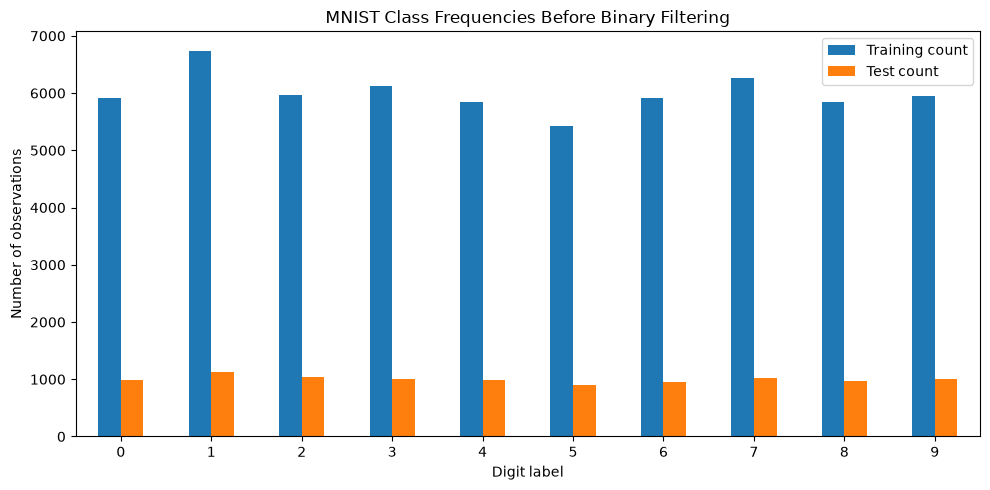

In [11]:
class_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("MNIST Class Frequencies Before Binary Filtering")
plt.xlabel("Digit label")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Class-frequency analysis

MNIST is not perfectly balanced across all ten digits, although the differences are
not extreme.

For the present experiment, the relevant question is whether digits 0 and 1 occur
in similar numbers. A large imbalance would affect the interpretation of accuracy
and might require class weighting or resampling.

The exact counts should be recorded rather than assuming that the binary subset is
balanced.

## 8. Filter the dataset to digits 0 and 1

In [12]:
train_binary_mask = np.isin(y_train_full, [0, 1])
test_binary_mask = np.isin(y_test_original, [0, 1])

X_train_binary_raw = X_train_full[train_binary_mask]
y_train_binary = y_train_full[train_binary_mask]

X_test_raw = X_test_original[test_binary_mask]
y_test = y_test_original[test_binary_mask]

print("Filtered training images:", X_train_binary_raw.shape)
print("Filtered training labels:", y_train_binary.shape)
print("Filtered test images:", X_test_raw.shape)
print("Filtered test labels:", y_test.shape)

Filtered training images: (12665, 28, 28)
Filtered training labels: (12665,)
Filtered test images: (2115, 28, 28)
Filtered test labels: (2115,)


In [13]:
assert X_train_binary_raw.shape[0] == y_train_binary.shape[0]
assert X_test_raw.shape[0] == y_test.shape[0]

In [14]:
print("Training labels after filtering:", np.unique(y_train_binary))
print("Test labels after filtering:", np.unique(y_test))

assert set(np.unique(y_train_binary)) == {0, 1}
assert set(np.unique(y_test)) == {0, 1}

print("Filtering validation passed.")

Training labels after filtering: [0 1]
Test labels after filtering: [0 1]
Filtering validation passed.


### Binary filtering result

The filtered target variable already uses the desired binary encoding:

- Digit 0 is represented by target value 0.
- Digit 1 is represented by target value 1.

Therefore, no additional label transformation is required.

This coding will later allow the network output to be interpreted as an estimated
probability:

\[
hat{p}_i = P(Y_i = 1 | X_i)
\]

Predictions at or above a selected threshold, initially 0.5, will be classified as
digit 1. Predictions below the threshold will be classified as digit 0.

## 9. Analyze class balance after filtering

In [15]:
binary_class_summary = pd.DataFrame({
    "Training count": pd.Series(y_train_binary).value_counts().sort_index(),
    "Test count": pd.Series(y_test).value_counts().sort_index(),
})

binary_class_summary.index = ["Digit 0", "Digit 1"]

binary_class_summary["Training proportion"] = (
    binary_class_summary["Training count"]
    / binary_class_summary["Training count"].sum()
)

binary_class_summary["Test proportion"] = (
    binary_class_summary["Test count"]
    / binary_class_summary["Test count"].sum()
)

binary_class_summary

,Training count,Test count,Training proportion,Test proportion
Digit 0,5923,980,0.467667,0.463357
Digit 1,6742,1135,0.532333,0.536643


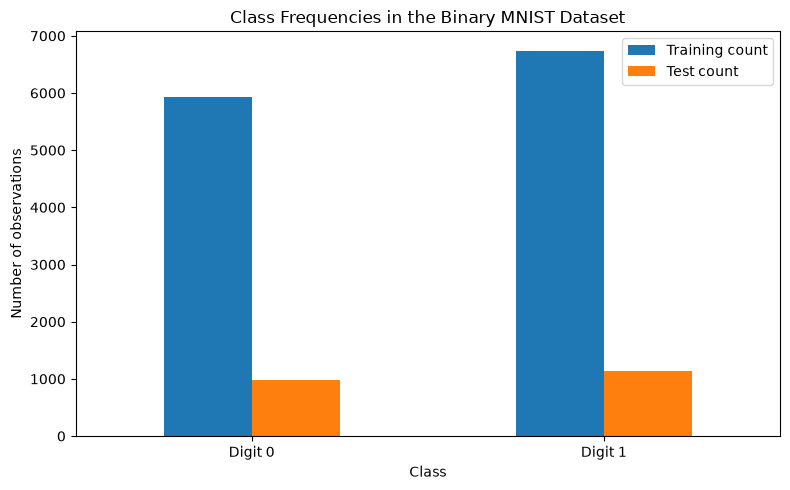

In [16]:
binary_class_summary[
    ["Training count", "Test count"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Class Frequencies in the Binary MNIST Dataset")
plt.xlabel("Class")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Binary class balance

The filtered dataset contains slightly different numbers of zeros and ones. The
difference should be quantified, but it is unlikely to be large enough to make
accuracy unusable.

Nevertheless, predictive evaluation will not rely exclusively on accuracy. Later
notebooks will also report:

- Precision
- Recall
- F1 score
- ROC-AUC
- Confusion matrix
- Binary cross-entropy loss

This prevents a seemingly high accuracy from hiding class-specific prediction
failures.

## 10. Visualize example images

In [17]:
def plot_digit_examples(
    images: np.ndarray,
    labels: np.ndarray,
    examples_per_class: int = 5,
) -> None:
    """Display randomly selected examples of digits 0 and 1."""
    
    figure, axes = plt.subplots(
        nrows=2,
        ncols=examples_per_class,
        figsize=(2 * examples_per_class, 4),
    )

    for row, digit in enumerate([0, 1]):
        digit_indices = np.flatnonzero(labels == digit)
        selected_indices = rng.choice(
            digit_indices,
            size=examples_per_class,
            replace=False,
        )

        for column, image_index in enumerate(selected_indices):
            axes[row, column].imshow(
                images[image_index],
                cmap="gray",
            )
            axes[row, column].set_title(f"Label: {digit}")
            axes[row, column].axis("off")

    plt.suptitle("Random Examples from the Binary MNIST Dataset")
    plt.tight_layout()
    plt.show()

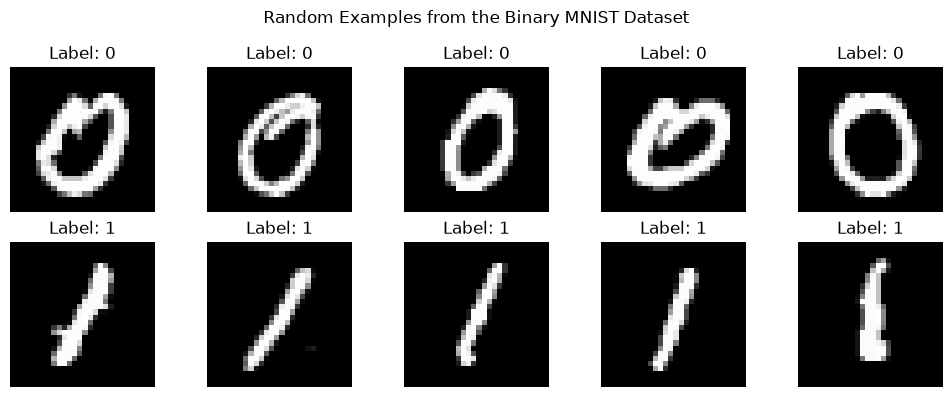

In [18]:
plot_digit_examples(
    images=X_train_binary_raw,
    labels=y_train_binary,
    examples_per_class=5,
)

### Qualitative image analysis

The sampled images show considerable variation within each class.

Potential sources of within-class variation include:

- Stroke thickness
- Digit position
- Digit scale
- Slant
- Curvature
- Incomplete or faint strokes

Despite this variation, zeros and ones have substantially different global shapes.
Zeros generally contain a closed or nearly closed curved region, while ones usually
contain a narrow vertical stroke.

This visual separation suggests that the binary task may be relatively easy. A
linear classifier may already perform well, making it important to include a simple
baseline later.

## 11. Examine average images

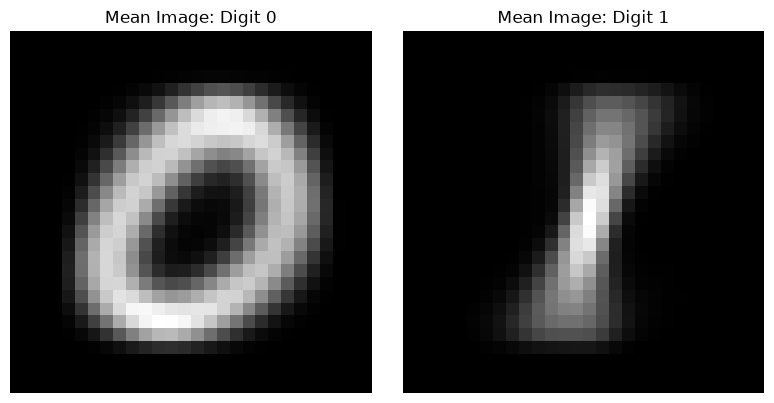

In [19]:
mean_zero_image = X_train_binary_raw[y_train_binary == 0].mean(axis=0)
mean_one_image = X_train_binary_raw[y_train_binary == 1].mean(axis=0)

figure, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(mean_zero_image, cmap="gray")
axes[0].set_title("Mean Image: Digit 0")
axes[0].axis("off")

axes[1].imshow(mean_one_image, cmap="gray")
axes[1].set_title("Mean Image: Digit 1")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Mean-image analysis

The mean images summarize the most common spatial intensity patterns within each
class.

The mean zero image should display a broad ring-like region, whereas the mean one
image should show greater intensity around the center vertical region.

The contrast between these class-level averages suggests that many individual pixels
contain useful class information. However, the mean image does not describe the full
distribution because averaging removes individual differences in writing style.

## 12. Pixel-level difference between classes

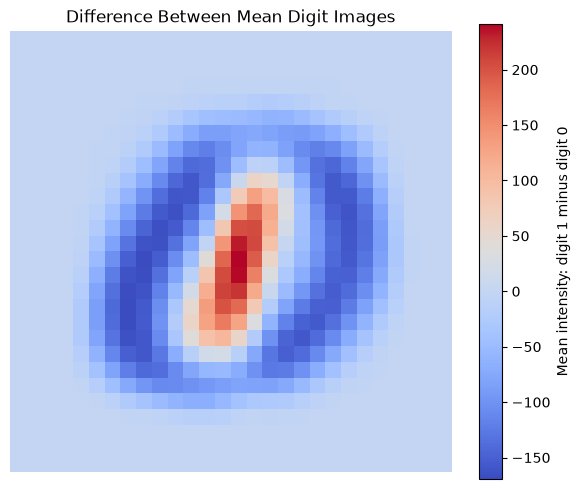

In [20]:
mean_difference = mean_one_image - mean_zero_image

plt.figure(figsize=(6, 5))
plt.imshow(mean_difference, cmap="coolwarm")
plt.colorbar(label="Mean intensity: digit 1 minus digit 0")
plt.title("Difference Between Mean Digit Images")
plt.axis("off")
plt.tight_layout()
plt.show()

### Mean-difference image

The difference image identifies pixel regions that distinguish the two classes.

- Positive regions indicate locations that tend to be brighter for ones.
- Negative regions indicate locations that tend to be brighter for zeros.
- Values close to zero indicate locations with similar average intensity.

The strong structured pattern supports the expectation that even a linear model
could separate many zeros and ones. The neural network will still be useful for
studying forward propagation, backpropagation, and implementation efficiency.